## Data Cleaning & Preprocessing

In [1]:
import pandas as pd
import numpy as np
import os
import re
from glob import glob

# Define column widths
widths = [4, 4, 3, 3, 3, 3, 7, 8, 8, 8, 8, 8, 7, 9, 6, 7, 7, 8, 8, 8, 8, 8, 8, 6, 6, 6, 7]

# Define column names
columns = [
    "Year", "Day", "Hour", "Minute", "IMF_ID", "SW_ID", "TimeShift",
    "BX", "BY", "BZ", "Speed", "Vx", "Density", "Temperature",
    "FlowPressure", "ElectricField", "PlasmaBeta",
    "Xgse", "Ygse", "Zgse", "BSN_X", "BSN_Y", "BSN_Z",
    "AE", "SYM_H", "ASY_H", "PCN"
]

# Missing value indicators
missing_values = [99.99, 999.99, 9999.99, 99999.9, 99999, 9999.99, 999999, 9999999.0]

# Folder paths
data_folder = "../Data/Omni_High_Res_Data/"
save_folder = "../Data/Omni_Cleaned/"

os.makedirs(save_folder, exist_ok=True)

# Gather all files
all_files = glob(os.path.join(data_folder, "*.lst"))

# Group files by year
year_to_files = {}

for file in all_files:
    filename = os.path.basename(file)
    
    # Find 4-digit year inside filename
    match = re.search(r"(19\d{2}|20\d{2})", filename)
    if match:
        year = int(match.group(0))
        year_to_files.setdefault(year, []).append(file)
    else:
        print(f"⚠️ Warning: No year found in {filename}")

# Process each year
for year in range(1981, 2026):
    files = year_to_files.get(year, [])

    if files:
        print(f"Processing {year}...")

        year_df_list = []

        for file in files:
            df = pd.read_fwf(file, widths=widths, names=columns)

            # Replace missing values
            df.replace(missing_values, np.nan, inplace=True)

            # Create Datetime
            df['Datetime'] = pd.to_datetime(
                df['Year'].astype(str) +
                df['Day'].astype(str).str.zfill(3) +
                df['Hour'].astype(str).str.zfill(2) +
                df['Minute'].astype(str).str.zfill(2),
                format='%Y%j%H%M',
                errors='coerce'
            )

            df.set_index('Datetime', inplace=True)
            year_df_list.append(df)

        # Concatenate all months (if multiple files)
        year_df = pd.concat(year_df_list)
        year_df.sort_index(inplace=True)

        # Drop bad timestamps
        year_df.dropna(subset=['Year', 'Day', 'Hour', 'Minute'], inplace=True)

        ### Fill missing values ###
        numeric_cols = year_df.select_dtypes(include=[np.number]).columns

        # Interpolate first
        year_df[numeric_cols] = year_df[numeric_cols].interpolate(method='linear', limit_direction='both')

        # Fill any still-missing with column mean
        year_df[numeric_cols] = year_df[numeric_cols].fillna(year_df[numeric_cols].mean())

        # Physically clip
        for col in ['Density', 'Temperature', 'Speed']:
            if col in year_df.columns:
                year_df[col] = year_df[col].clip(lower=0)

        # Save
        save_path = os.path.join(save_folder, f"omni_{year}.csv")
        year_df.to_csv(save_path)
        print(f"✅ Saved cleaned data for {year} -> {save_path}")

    else:
        print(f"⚠️ Warning: No files found for {year}!")

print("🎉 All years processed successfully!")


Processing 1981...
✅ Saved cleaned data for 1981 -> ../Data/Omni_Cleaned/omni_1981.csv
Processing 1982...
✅ Saved cleaned data for 1982 -> ../Data/Omni_Cleaned/omni_1982.csv
Processing 1983...
✅ Saved cleaned data for 1983 -> ../Data/Omni_Cleaned/omni_1983.csv
Processing 1984...
✅ Saved cleaned data for 1984 -> ../Data/Omni_Cleaned/omni_1984.csv
Processing 1985...
✅ Saved cleaned data for 1985 -> ../Data/Omni_Cleaned/omni_1985.csv
Processing 1986...
✅ Saved cleaned data for 1986 -> ../Data/Omni_Cleaned/omni_1986.csv
Processing 1987...
✅ Saved cleaned data for 1987 -> ../Data/Omni_Cleaned/omni_1987.csv
⚠️ Warning: No files found for 1988!
Processing 1989...
✅ Saved cleaned data for 1989 -> ../Data/Omni_Cleaned/omni_1989.csv
Processing 1990...
✅ Saved cleaned data for 1990 -> ../Data/Omni_Cleaned/omni_1990.csv
Processing 1991...
✅ Saved cleaned data for 1991 -> ../Data/Omni_Cleaned/omni_1991.csv
Processing 1992...
✅ Saved cleaned data for 1992 -> ../Data/Omni_Cleaned/omni_1992.csv
Proces

## Load Cleaned Data and Plot Time Series

⚠️ Warning: File not found for 1988, skipping...
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 24724800 entries, 1981-01-01 00:00:00 to 2025-03-31 23:59:00
Data columns (total 3 columns):
 #   Column  Dtype  
---  ------  -----  
 0   BZ      float64
 1   Vx      float64
 2   AE      float64
dtypes: float64(3)
memory usage: 754.5 MB
None


C:\Users\hp\AppData\Local\Temp\ipykernel_16972\3704157471.py:51: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
c:\Users\hp\Downloads\Space_Weather_Event_Analysis\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


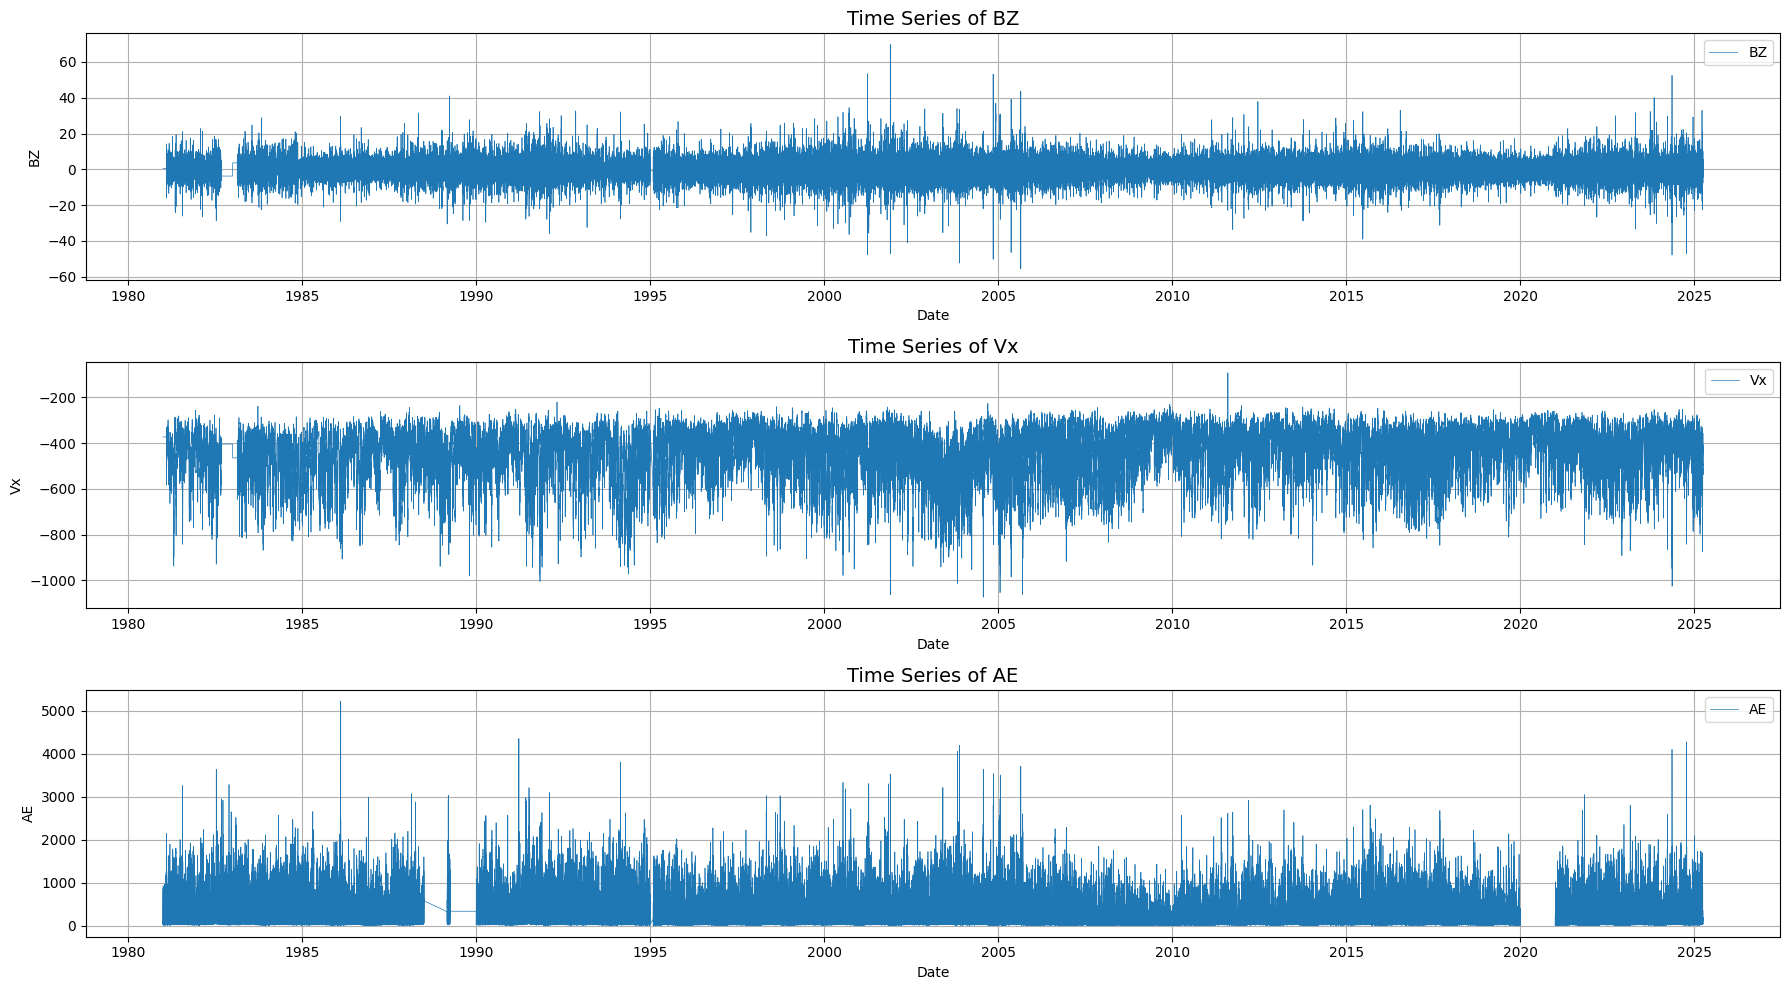

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import os

# Folder where cleaned data is saved
cleaned_folder = "../Data/Omni_Cleaned/"

# Select years you want to plot
start_year = 1981
end_year = 2025

# Variables you want to plot
variables_to_plot = ['BZ', 'Vx', 'AE']

# Prepare an empty DataFrame
all_data = []

# Read each year's data and collect
for year in range(start_year, end_year + 1):
    file_path = os.path.join(cleaned_folder, f"omni_{year}.csv")
    
    if os.path.exists(file_path):
        df = pd.read_csv(file_path, parse_dates=['Datetime'], index_col='Datetime')

        # Only keep required columns
        df = df[variables_to_plot]
        
        all_data.append(df)
    else:
        print(f"⚠️ Warning: File not found for {year}, skipping...")

# Combine all years into one big DataFrame
full_df = pd.concat(all_data)

# Quick check
print(full_df.info())

# ---- Plotting ---- #

plt.figure(figsize=(18, 10))

for i, var in enumerate(variables_to_plot, 1):
    plt.subplot(3, 1, i)
    plt.plot(full_df.index, full_df[var], label=var, linewidth=0.5)
    plt.title(f"Time Series of {var}", fontsize=14)
    plt.xlabel("Date")
    plt.ylabel(var)
    plt.grid(True)
    plt.legend()

plt.tight_layout()
plt.show()
